In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'
from sklearn.cluster import KMeans, MiniBatchKMeans
import numpy as np
import librosa
from glob import glob
from umap import UMAP
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model, Model
import random 
import math
from tqdm import tqdm
from tensorflow.keras.utils import Sequence
 
from sklearn.metrics import roc_curve, auc
from audiomentations import Compose, Normalize, Gain
from mygenerator import MyGenerator

 
mfname = "/home/gary/sancsound/exp2/best_exp2_22"
fnames = glob("/home/gary/sancsound/goldclips/*")  #this is stellwagon


2023-10-21 13:58:00.362890: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-21 13:58:01.094512: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
N = 4096  # length of 
DROPOUT = 0
SR = 96000

random.shuffle(fnames)
mygen = MyGenerator(fnames, 64, N=N, dropout=DROPOUT, sr=SR)


In [4]:
x,y =mygen.__getitem__(0)
 

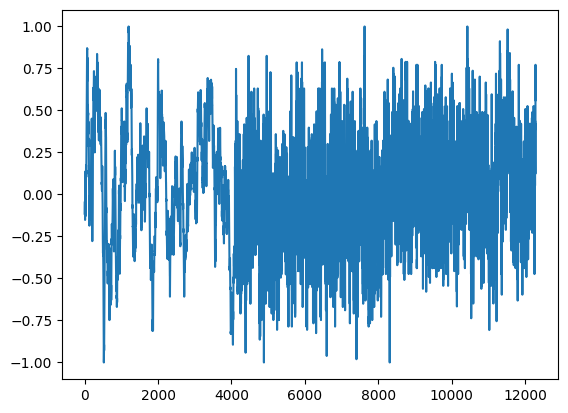

In [7]:
plt.plot(x[10]) 

In [ ]:
def plotModel(fp,tp, thisname, thisauc):
    plt.plot(fp,tp, label=f"{thisname} {thisauc:0.2f}")
    plt.plot([0,1],[0,1], linestyle='--',c='r')
    plt.grid( which='major', linestyle='-',c='k')
    plt.grid( which='minor', linestyle='--',c='r')

    plt.xlabel("False Positlves")
    plt.ylabel("True Positives")
    plt.legend()    
    plt.title("NOAA Passive Acoustic Data - Self Supervised Learning ")


def doModel(m, thisgenerator):

    model = load_model(m)
    thisname = m
    y_test = []
    y_hat = []
    for i in  tqdm(range(100)):
        x,y = thisgenerator.__getitem__(i)  # remind that generator does augmentation
        ytmp = model.predict(x, verbose=0)
        y_test.append(y)
        y_hat.append(ytmp)
    y_test = np.hstack(y_test)
    y_hat = np.vstack (y_hat)
    fp,tp, th = roc_curve(y_test, y_hat)
    thisauc = auc(fp,tp)
    plotModel(fp,tp, thisname, thisauc)
    plt.show()
    
    


In [ ]:
doModel(mfname, mygen)